# DynaMate — Tutorial: Dynamic Multi-Agent Loop

This notebook walks through the complete **add → use → remove** lifecycle
of the DynaMate supervisor framework using a scientifically motivated example.

| Phase | Action |
|-------|--------|
| **1. Build** | Assemble the initial system and inspect the architecture |
| **2. Add** | Register a tool and create a dynamic agent via natural language |
| **3. Use** | Run a computation routed through the **Prompt Enhancer → Supervisor** pipeline |
| **4. Remove** | Delete the agent and tool, restoring the original architecture |

**Scientific context:** The Boltzmann thermal energy *kT* is the fundamental energy scale
in statistical mechanics and molecular simulation. We will register a `boltzmann_energy`
function as a tool, assign it to a dedicated `thermal_agent`, run a two-tool Arrhenius
calculation using the Prompt Enhancer, then cleanly remove both the agent and the tool.

---

### Framework overview

```
User prompt  (natural language — no tool/agent names required)
    │
    ▼
PromptEnhancer            ← lightweight LLM; reads live pool state and rewrites
    │                        the query with explicit routing hints
    ▼
Supervisor                ← LLM router; always reflects the current pool
    ├── tool_manager      ← registers tools, assigns them, adds/removes agents
    ├── shell_agent       ← runs shell commands (has terminal base tool)
    ├── compute_agent     ← general computation (starts empty)
    └── [dynamic agents]  ← created at runtime; persisted across sessions
              ▲
         AgentPool  (shared state)
         ├── _tool_registry   {name → StructuredTool}
         ├── _source_registry {name → source_code}  ← for persistence
         └── _agents          {name → {model, base_tools, extra_tools, ...}}
```

> **Package:** `dynamate` — built on LangGraph and `langgraph-supervisor`.
> Every pool mutation is written to `pool_state.json` immediately.

---
## 1 — Setup and System Initialization

DynaMate is assembled in **four ordered steps** to resolve the dependency between
the ToolManager (needs a pool reference) and the Supervisor (needs the ToolManager):

| Step | Call | Effect |
|------|------|--------|
| 1 | `PersistentAgentPoolWithSupervisor(...)` | Pool created; no supervisor yet |
| 2 | `pool.add_agent(...)` × 2 | `shell_agent` and `compute_agent` added |
| 3 | `build_tool_manager_v2(pool, model)` | ToolManager compiled, bound to the live pool |
| 4 | `pool.set_system_agents([tool_manager])` | **First supervisor build triggered** |

**Why `_is_dynamic=False` for the initial agents?**
Initial agents are always rebuilt from `main.py` on startup (they hold Python objects like
`ShellTool` that cannot be serialized). Setting `_is_dynamic=False` tells the persistent
pool to skip saving them to `pool_state.json`.

> **Isolation:** This tutorial writes to a temporary directory and does **not** affect
> your real `.dynamate/` session.

In [33]:
import sys, os, tempfile
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import dotenv
dotenv.load_dotenv()

from IPython.display import display, Image,Markdown
from langchain_openai import ChatOpenAI
from langchain_community.tools import ShellTool
from dynamate import (
    PersistentAgentPoolWithSupervisor,
    PersistentSaver,
    PoolStore,
    PromptEnhancer,
    build_tool_manager_v2,
    pretty_print_messages,
    register_tools_from_prompt,
)

MODEL_NAME = 'gpt-4.1-mini'
model = ChatOpenAI(model=MODEL_NAME,temperature=0)

print(f'Model  : {MODEL_NAME}')
print('Imports: OK')

Model  : gpt-4.1-mini
Imports: OK


In [34]:
# ── Persistent state directory ────────────────────────────────────────────────
# tools/           ← one .py file per registered tool (human-editable)
# pool_state.json  ← agent definitions + assignments (no source code)
# conversations.db ← conversation history (SQLite)
STATE_DIR = os.path.join(os.path.abspath("."), "paper_tests_7_state")

SUPERVISOR_PROMPT = '''You are the Supervisor managing a pool of agents.
- tool_manager              : registers tools, assigns them to agents, and adds/removes agents.
- shell_agent               : runs shell commands and handles file-system tasks.
- compute_agent             : performs calculations with its dynamically assigned tools.

Routing rules:
  * Add/register/assign/remove/list tools or agents -> tool_manager.
  * Python code (def statements) + add/register intent -> tool_manager.
  * Shell or file-system tasks -> shell_agent.
  * Domain tasks (download, simulate, generate, compute, create files) ->
    the specialist agent that owns the relevant tool. Do NOT route these
    to tool_manager — tool_manager only manages the pool, it cannot execute
    domain work.
  * If no specialist exists for the task, ask tool_manager to create one first.

Execution rules:
  * If you have all you need execute tasks immediately. 
  * When a specialist agent completes a calculation, report the full numerical
    result directly. Do not say "the agent is ready" or ask what to do next.
  * Assign work to one agent at a time.'''

# Step 1 — persistence layers
saver      = PersistentSaver(os.path.join(STATE_DIR, "conversations.db"))
pool_store = PoolStore(os.path.join(STATE_DIR, "pool_state.json"))

# Step 2 — create pool (no supervisor yet)
pool = PersistentAgentPoolWithSupervisor(
    supervisor_model=model,
    pool_store=pool_store,
    supervisor_prompt=SUPERVISOR_PROMPT,
    checkpointer=saver,
)

# Step 3 — add initial agents (_is_dynamic=False: not written to pool_state.json)
pool.add_agent(
    name="shell_agent",
    model=model,
    base_tools=[ShellTool()],
    system_prompt="You are a shell agent. Execute shell commands to answer requests.",
    _is_dynamic=False,
)
pool.add_agent(
    name="compute_agent",
    model=model,
    base_tools=[],
    system_prompt="You are a computation agent. Use your dynamically assigned tools to answer requests. Always call your tools and return the numerical result.",
    _is_dynamic=False,
)

# Step 4 — build ToolManager and trigger first supervisor build
tool_manager = build_tool_manager_v2(pool, model)
pool.set_system_agents([tool_manager])

# Step 5 — restore previously saved tools, agents, and assignments (no-op on first run)
model_factory = lambda name: ChatOpenAI(model=name, temperature=0.0)
pool.restore_state(model_factory)

# Step 6 — build PromptEnhancer (wraps the same model; queries pool live on each call)
enhancer = PromptEnhancer(model=model, pool=pool)

print("System ready.")
print(f"Agents   : {pool.list_agents()}")
print(f"Tools    : {pool.list_registered_tools() or 'none'}")
print(f"Enhancer : {enhancer.__class__.__name__} ready")
print(f"State    : {STATE_DIR}")

State restored — 4 tool(s), 1 dynamic agent(s), 4 assignment(s).
System ready.
Agents   : ['shell_agent', 'compute_agent', 'mace_md_specialist']
Tools    : ['download_mace_model', 'packmol_build_system', 'run_nvt_md', 'smiles_to_xyz']
Enhancer : PromptEnhancer ready
State    : /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/paper_tests_7_state


In [35]:
def print_pool_state(pool, label='POOL STATE'):
    'Print a concise snapshot of the current pool agents and their tools.'
    sep = '=' * 58
    print(f'\n{sep}')
    print(f'  {label}')
    print(sep)
    print(f'  Agents   : {pool.list_agents()}')
    print(f'  Registry : {pool.list_registered_tools() or "(empty)"}')
    print()
    for name in pool.list_agents():
        entry = pool._agents[name]
        base  = [t.name for t in entry['base_tools']]
        extra = [t.name for t in entry['extra_tools']]
        print(f'  [{name}]')
        print(f'    base tools    : {base or "(none)"}')
        print(f'    assigned tools: {extra or "(none)"}')
    print(sep)

── Initial Architecture ─────────────────────────────────────


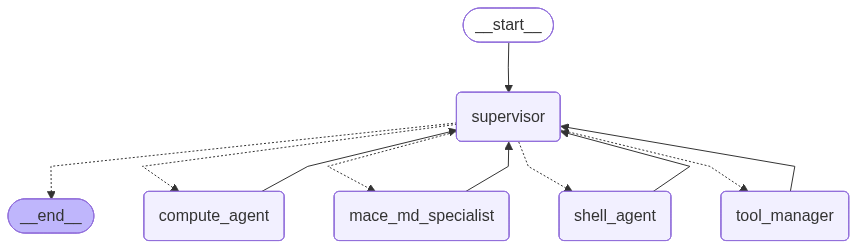


  INITIAL STATE
  Agents   : ['shell_agent', 'compute_agent', 'mace_md_specialist']
  Registry : ['download_mace_model', 'packmol_build_system', 'run_nvt_md', 'smiles_to_xyz']

  [shell_agent]
    base tools    : ['terminal']
    assigned tools: (none)
  [compute_agent]
    base tools    : (none)
    assigned tools: (none)
  [mace_md_specialist]
    base tools    : (none)
    assigned tools: ['download_mace_model', 'smiles_to_xyz', 'packmol_build_system', 'run_nvt_md']


In [36]:
print('── Initial Architecture ─────────────────────────────────────')
display(Image(pool.supervisor.get_graph().draw_mermaid_png()))

mermaid_code = pool.supervisor.get_graph().draw_mermaid()
# Add a custom style for a node named 'supervisor'
mermaid_code += "\nclassDef supervisor fill:#f96,stroke:#333,stroke-width:4px;"
mermaid_code += "\nclass supervisor supervisor;"

#display(Image(f"```mermaid\n{mermaid_code}\n```"))

print_pool_state(pool, 'INITIAL STATE')

---
## 3.1 Tool Addition

**What we're testing:** A user can extend the system with new capabilities by pasting Python
functions into a plain-language prompt. The supervisor routes to `tool_manager`, which registers
the function in the global registry. No specialist agent needs to exist yet.

**Tools registered in this section:**
- `download_mace_model` — downloads a MACE foundation model by name; has a built-in URL dictionary
- `generate_liquid_box` — builds a simulation system from a SMILES string:
  - single optimized molecule XYZ if no box parameters given
  - periodic liquid box if `n_molecules` **and** `density_gcc` are provided

**PromptEnhancer role:** Only `tool_manager` is in the pool at this stage; the enhancer routes
both registration requests to it automatically.

In [37]:
# ── Tool source code strings ────────────────────────────────────────────────
# These are passed verbatim to the system as part of the user prompt.

DOWNLOAD_MACE_MODEL_CODE = '''
def download_mace_model(model_name: str,
                        output_dir: str = '.',
                        model_dict: dict = None,
                        convert_lmp: bool = True):
    """
    Download a MACE foundation model by name from the ACEsuit repositories.

    If the model file already exists in output_dir it will not be downloaded again.
    With convert_lmp=True the model is also converted to LAMMPS format and the
    .pt path is returned; otherwise the raw .model path is returned.

    Parameters
    ----------
    model_name : str  -- canonical model identifier (key in model_dict)
    output_dir : str  -- directory where the file will be saved
    model_dict : dict -- mapping model_name -> URL (uses built-in dict if None)
    convert_lmp : bool -- convert to LAMMPS format after download

    Returns
    -------
    str -- path to the downloaded (or existing) model file
    """
    ## Imports
    import os, subprocess

    if model_dict is None:
        model_dict = {
            "MACE-MP-0b":  "https://github.com/ACEsuit/mace-foundations/releases/download/mace_mp_0b/mace_agnesi_medium.model",
            "MACE-MP-0b2": "https://github.com/ACEsuit/mace-foundations/releases/download/mace_mp_0b2/mace-large-density-agnesi-stress.model",
            "MACE-MP-0b3": "https://github.com/ACEsuit/mace-foundations/releases/download/mace_mp_0b3/mace-mp-0b3-medium.model",
            "MACE-MPA-0":  "https://github.com/ACEsuit/mace-mp/releases/download/mace_mpa_0/mace-mpa-0-medium.model",
            "MACE-OMAT-0": "https://github.com/ACEsuit/mace-mp/releases/download/mace_omat_0/mace-omat-0-medium.model",
            "MACE-MATPES-PBE-0":    "https://github.com/ACEsuit/mace-foundations/releases/download/mace_matpes_0/MACE-matpes-pbe-omat-ft.model",
            "MACE-MATPES-r2SCAN-0": "https://github.com/ACEsuit/mace-foundations/releases/download/mace_matpes_0/MACE-matpes-r2scan-omat-ft.model",
            "MACE-MH-0":   "https://github.com/ACEsuit/mace-foundations/releases/download/mace_mh_1/mace-mh-0.model",
        }

    if model_name not in model_dict:
        raise ValueError(
            f"Model '{model_name}' not found. Available: {list(model_dict.keys())}"
        )

    url      = model_dict[model_name]
    fname    = os.path.basename(url)
    out_path = os.path.join(output_dir, fname)

    if os.path.exists(out_path):
        print(f"Model '{model_name}' already exists at {out_path}. Skipping download.")
    else:
        os.makedirs(output_dir, exist_ok=True)
        print(f"Downloading '{model_name}' from:\n{url}\n-> {out_path}")
        subprocess.run(["wget", "-O", out_path, url], check=True)
        print(f"Download complete: {out_path}")

    if convert_lmp:
        print(f"Converting '{model_name}' to LAMMPS format.")
        os.system(f"python ~/mace/mace/cli/create_lammps_model.py {out_path}")
        return out_path + '-lammps.pt'
    return out_path
'''

SMILES_TO_XYZ_CODE = '''
def smiles_to_xyz(smiles: str, output_path: str = 'molecule.xyz') -> str:
    """
    Convert a SMILES string to a 3D XYZ file using RDKit.

    Generates 3D coordinates with ETKDG and optimises with UFF force field.
    If the output file already exists it is returned immediately without
    regenerating coordinates.

    Parameters
    ----------
    smiles      : str -- SMILES string of the molecule
    output_path : str -- path for the output .xyz file

    Returns
    -------
    str -- path to the written XYZ file
    """
    from rdkit import Chem
    from rdkit.Chem import AllChem
    import os

    if os.path.exists(output_path):
        print(f"Output file '{output_path}' already exists. Skipping SMILES conversion.")
        return output_path

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Invalid SMILES: {smiles}')
    mol = Chem.AddHs(mol)
    if AllChem.EmbedMolecule(mol, AllChem.ETKDG()) != 0:
        raise RuntimeError('3D embedding failed for SMILES: ' + smiles)
    AllChem.UFFOptimizeMolecule(mol)
    conf = mol.GetConformer()

    symbols   = [atom.GetSymbol() for atom in mol.GetAtoms()]
    positions = [
        (conf.GetAtomPosition(i).x,
         conf.GetAtomPosition(i).y,
         conf.GetAtomPosition(i).z)
        for i in range(mol.GetNumAtoms())
    ]

    os.makedirs(os.path.dirname(os.path.abspath(output_path)), exist_ok=True)
    with open(output_path, 'w') as f:
        f.write(f'{len(symbols)}\n')
        f.write(f'SMILES: {smiles}\n')
        for sym, (x, y, z) in zip(symbols, positions):
            f.write(f'{sym:<3} {x:>12.6f} {y:>12.6f} {z:>12.6f}\n')
    return output_path
'''

PACKMOL_BUILD_SYSTEM_CODE = '''
def packmol_build_system(
    xyz_files,
    box_size: float,
    n_molecules=1,
    output_file: str = 'system.xyz',
    tolerance: float = 2.5
):
    """
    Build a molecular system using Packmol by placing one or more molecules
    in a cubic box.

    If the output file already exists it is returned immediately without
    re-running Packmol.

    Parameters
    ----------
    xyz_files   : str or list of str -- path(s) to input XYZ file(s)
    box_size    : float              -- size of the cubic box (Angstrom)
    n_molecules : int or list of int -- number of copies for each molecule
    output_file : str                -- output file path
    tolerance   : float              -- minimum atom-atom distance (Angstrom)

    Returns
    -------
    str -- path to the generated system XYZ file
    """
    import subprocess
    import os

    if isinstance(xyz_files, str):
        xyz_files = [xyz_files]
    if isinstance(n_molecules, int):
        n_molecules = [n_molecules] * len(xyz_files)
    if len(xyz_files) != len(n_molecules):
        raise ValueError('Length of xyz_files and n_molecules must match')

    if os.path.exists(output_file):
        print(f"Output file '{output_file}' already exists. Skipping Packmol build.")
        return output_file

    if subprocess.call(['which', 'packmol'],
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL) != 0:
        raise EnvironmentError(
            'Packmol is not found in PATH. Please install or load it first.'
        )

    input_filename = 'packmol_input.inp'
    with open(input_filename, 'w') as f:
        f.write(f'tolerance {tolerance}\n')
        f.write('filetype xyz\n')
        f.write(f'output {output_file}\n')
        f.write('seed 12345\n\n')
        for xyz, n in zip(xyz_files, n_molecules):
            f.write(f'structure {xyz}\n')
            f.write(f'  number {n}\n')
            f.write(f'  inside box 0. 0. 0. {box_size} {box_size} {box_size}\n')
            f.write('end structure\n\n')

    print(f'Running Packmol to build system in a {box_size} A box...')
    os.system(f'packmol < {input_filename}')

    if not os.path.exists(output_file):
        raise FileNotFoundError('Packmol did not produce the expected output file.')

    print(f'System built successfully: {output_file}')
    return output_file
'''

print("Tool code strings defined.")

Tool code strings defined.


## 3.1 Tool Addition

**Objective:** Demonstrate that a user can extend the system by pasting Python functions and
asking to "add this capability." The supervisor routes to `tool_manager`, which registers both
functions. No domain agent needs to exist yet.


In [38]:


# user_prompt_A = """
#     I have a Python function that can download MACE machine learning potential 
#     models by name — it knows the download URLs for several standard models 
#     (MACE-MP-0b3, MACE-MPA-0, etc.) and skips re-downloading if the file 
#     already exists. Please add it to the system so I can use it later.\n\n
# """ + DOWNLOAD_MACE_MODEL_CODE

# print(user_prompt_A)

In [39]:

user_prompt_A = """
    I have a Python function that can download MACE machine learning potential 
    models by name — it knows the download URLs for several standard models 
    (MACE-MP-0b3, MACE-MPA-0, etc.) and skips re-downloading if the file 
    already exists. Please add it to the system so I can use it later.\n\n
""" + DOWNLOAD_MACE_MODEL_CODE

# ── Old implementation (register_tools_from_prompt) ───────────────────────
# result = register_tools_from_prompt(user_prompt_A, pool, model)
# print(f'Registration : {result}')
# print(f'Registry now : {pool.list_registered_tools()}')
# # ── Verify the tool was registered correctly ──────────────────────────
# registered = pool.list_registered_tools()
# assert "download_mace_model" in registered, "download_mace_model not in registry!"
# print_pool_state(pool, 'TOOL 1 STATE')

# ── New implementation (enhancer → supervisor pipeline) ───────────────────
config_A = {'configurable': {'thread_id': 'test-thread-1'}}

print("── [enhancer] " + "─" * 44)
enhanced_A = enhancer.enhance(user_prompt_A)
print(enhanced_A)
print()

print("── [supervisor] " + "─" * 42)
print('Sending tool registration prompt to Supervisor...\n')
for chunk in pool.supervisor.stream(
    {'messages': [{'role': 'user', 'content': user_prompt_A}]},
    config=config_A,
    recursion_limit=20,
):
    pretty_print_messages(chunk, last_message=True)

registered = pool.list_registered_tools()
assert "download_mace_model" in registered, "download_mace_model not in registry!"
print_pool_state(pool, 'TOOL 1 STATE')


── [enhancer] ────────────────────────────────────────────



    I have a Python function that can download MACE machine learning potential 
    models by name — it knows the download URLs for several standard models 
    (MACE-MP-0b3, MACE-MPA-0, etc.) and skips re-downloading if the file 
    already exists. Please add it to the system so I can use it later.



def download_mace_model(model_name: str,
                        output_dir: str = '.',
                        model_dict: dict = None,
                        convert_lmp: bool = True):
    """
    Download a MACE foundation model by name from the ACEsuit repositories.

    If the model file already exists in output_dir it will not be downloaded again.
    With convert_lmp=True the model is also converted to LAMMPS format and the
    .pt path is returned; otherwise the raw .model path is returned.

    Parameters
    ----------
    model_name : str  -- canonical model identifier (key in model_dict)
    output_dir : str  -- directory where the file will be saved
    model_dict : dict 

---
## 3.2 — Add: Register a Second Tool and Create a Dynamic Agent

In this phase we:
1. Register `arrhenius_factor` via a natural-language prompt (same pattern as Phase 1)
2. Ask the supervisor (through the PromptEnhancer) to create a `thermal_agent` and equip it with both tools

The user never names any internal framework objects — they just describe what they want.

In [40]:
user_prompt_B = """
    Here are two functions I would like to add to the system.
    The first converts a SMILES string to a 3D XYZ file using RDKit.
    The second builds a periodic molecular simulation box using Packmol —
    it takes one or more XYZ files and places copies of the molecules inside
    a cubic box of a given size. Please register both so I can use them later.\n\n
""" + SMILES_TO_XYZ_CODE + "\n" + PACKMOL_BUILD_SYSTEM_CODE

# ── Old implementation (register_tools_from_prompt) ───────────────────────
# result = register_tools_from_prompt(user_prompt_B, pool, model)
# print(f'Registration : {result}')
# print(f'Registry now : {pool.list_registered_tools()}')

# ── New implementation (enhancer → supervisor pipeline) ───────────────────
config_B = {'configurable': {'thread_id': 'test-thread-1'}}

print("── [enhancer] " + "─" * 44)
enhanced_B = enhancer.enhance(user_prompt_B)
print(enhanced_B)
print()

print("── [supervisor] " + "─" * 42)
print('Sending tool registration prompt to Supervisor...\n')
for chunk in pool.supervisor.stream(
    {'messages': [{'role': 'user', 'content': enhanced_B}]},
    config=config_B,
    recursion_limit=20,
):
    pretty_print_messages(chunk, last_message=True)

registered = pool.list_registered_tools()
assert "smiles_to_xyz" in registered, "smiles_to_xyz not in registry!"
assert "packmol_build_system" in registered, "packmol_build_system not in registry!"
print_pool_state(pool, 'TOOL 2 STATE')


── [enhancer] ────────────────────────────────────────────

    Here are two functions I would like to add to the system.
    The first converts a SMILES string to a 3D XYZ file using RDKit.
    The second builds a periodic molecular simulation box using Packmol —
    it takes one or more XYZ files and places copies of the molecules inside
    a cubic box of a given size. Please register both so I can use them later.



def smiles_to_xyz(smiles: str, output_path: str = 'molecule.xyz') -> str:
    """
    Convert a SMILES string to a 3D XYZ file using RDKit.

    Generates 3D coordinates with ETKDG and optimises with UFF force field.
    If the output file already exists it is returned immediately without
    regenerating coordinates.

    Parameters
    ----------
    smiles      : str -- SMILES string of the molecule
    output_path : str -- path for the output .xyz file

    Returns
    -------
    str -- path to the written XYZ file
    """
    from rdkit import Chem
    from rdkit.

In [41]:
# ── Create mace_agent and assign both tools via the supervisor pipeline ────
# The user describes what they want; PromptEnhancer routes to tool_manager.
user_prompt_C = """
I need a dedicated specialist in MACE and molecular dynamics simulations.
Please create one and give it the three tools I just added.\n\n
""" 

#config_setup = {'configurable': {'thread_id': 'setup'}}
config_setup = {'configurable': {'thread_id': 'test-thread-1'}}

print("── [enhancer] " + "─" * 44)
enhanced = enhancer.enhance(user_prompt_C)
print(enhanced)
print()

print("── [supervisor] " + "─" * 42)
print('Sending setup prompt to Supervisor...\n')
for chunk in pool.supervisor.stream(
    {'messages': [{'role': 'user', 'content': enhanced}]},
    config=config_setup,
    recursion_limit=20,
):
    pretty_print_messages(chunk, last_message=True)

    

── [enhancer] ────────────────────────────────────────────

I need a dedicated specialist in MACE and molecular dynamics simulations.
Please create one and give it the three tools I just added.



Use tool_manager — it MUST immediately call register_tool_from_code with the complete function code as the argument to complete the request.

── [supervisor] ──────────────────────────────────────────
Sending setup prompt to Supervisor...

Update from node supervisor:

================================= Tool Message =================================
Name: transfer_to_tool_manager

Successfully transferred to tool_manager

Update from node tool_manager:

================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor

Update from node supervisor:

================================== Ai Message ==================================
Name: supervisor

There is already a specialist agent named "mace_md_speci

In [42]:
# ── Verify the tool was registered correctly ─────────────────────────────
registered = pool.list_registered_tools()
#assert "packmol_build_system" in registered, "packmol_build_system not in registry!"
print_pool_state(pool, 'STATE AFTER TOOL 2 REGISTRATION AND AGENT SETUP')


  STATE AFTER TOOL 2 REGISTRATION AND AGENT SETUP
  Agents   : ['shell_agent', 'compute_agent', 'mace_md_specialist']
  Registry : ['download_mace_model', 'packmol_build_system', 'run_nvt_md', 'smiles_to_xyz']

  [shell_agent]
    base tools    : ['terminal']
    assigned tools: (none)
  [compute_agent]
    base tools    : (none)
    assigned tools: (none)
  [mace_md_specialist]
    base tools    : (none)
    assigned tools: ['download_mace_model', 'smiles_to_xyz', 'packmol_build_system', 'run_nvt_md']


In [43]:
# ── Inspect and repair mace_md_specialist system prompt ──────────────────────
# The LLM-generated system prompt may not include the execution rule.
# Patch it directly so we don't need to re-run from the top.

EXECUTION_RULE = (
    "\nAlways call your available tools to complete every request and return "
    "the full result. Never transfer back to the supervisor before your tools "
    "have been executed and you have a concrete answer."
    "\nBefore calling any preparation tool (smiles_to_xyz, packmol_build_system, "
    "download_mace_model), check whether the required output file already exists "
    "on disk. If it does, skip that preparation step entirely and proceed directly "
    "to the requested operation. Only invoke preparation tools when the required "
    "files are genuinely absent."
    "\nEach tool performs exactly one complete step — once it returns a result "
    "(file path or completion message), that step is finished. Do not call the "
    "same tool again for the same output; proceed immediately to the next "
    "required step."
)

specialist_name = "mace_md_specialist"
current_prompt = pool._agents[specialist_name]["system_prompt"]
print(f"Current system prompt for '{specialist_name}':\n{current_prompt}\n")

if EXECUTION_RULE.strip() not in current_prompt:
    patched = current_prompt + EXECUTION_RULE
    pool._agents[specialist_name]["system_prompt"] = patched
    pool._agents[specialist_name]["base_system_prompt"] = patched
    # Rebuild the agent in the pool so the new prompt takes effect
    pool._rebuild_agent(specialist_name)
    pool._rebuild_supervisor()
    print("✓ Execution rule appended — agent and supervisor rebuilt.")
else:
    print("✓ Execution rule already present — no change needed.")

Current system prompt for 'mace_md_specialist':
You are a specialist in MACE machine learning potentials and molecular dynamics simulations. Always call your tools immediately and return the complete numerical result.
Your FIRST action must ALWAYS be to call one of your assigned tools.
Do NOT call transfer_back_to_supervisor until AFTER a tool has returned a result.
If all the needed data is available call the tool immediately and do not ask for confirmation. Excecuthe the tool suggested in the prompt.
Always call your available tools to complete every request and return the full result. Never transfer back to the supervisor before your tools have been executed and you have a concrete answer.
Before calling any preparation tool (smiles_to_xyz, packmol_build_system, download_mace_model), check whether the required output file already exists on disk. If it does, skip that preparation step entirely and proceed directly to the requested operation. Only invoke preparation tools when the req

### Prompt C — Verify supervisor knowledge of registered capabilities

The user asks what the system can do. Expected: both tools appear in the registry.

In [44]:
user_input_C = "What capabilities have been added to the system so far?"

enhanced_C = enhancer.enhance(user_input_C)
if enhanced_C != user_input_C:
    print(f'[enhancer]\n{enhanced_C}\n')

#config_setup = {'configurable': {'thread_id': 'setup'}}
config_setup ={'configurable': {'thread_id': 'test-thread-1'}}

for chunk in pool.supervisor.stream(
    {"messages": [{"role": "user", "content": enhanced_C}]},
    config=config_setup,
    recursion_limit=10,
):
    pretty_print_messages(chunk, last_message=True)

Update from node supervisor:

================================== Ai Message ==================================
Name: supervisor

The system currently has the following capabilities added:

1. download_mace_model: Download MACE machine learning potential models by name from ACEsuit repositories, with optional conversion to LAMMPS format.

2. smiles_to_xyz: Convert a SMILES string to a 3D XYZ molecular structure file using RDKit, generating 3D coordinates and optimizing with the UFF force field.

3. packmol_build_system: Build a molecular simulation system by placing one or more molecules (from XYZ files) inside a cubic box using Packmol, with control over molecule counts and packing tolerance.

4. run_nvt_md: Run NVT molecular dynamics simulations with periodic boundary conditions using ASE (from the registered file ASE_NVT_PBC.py).

These tools are assigned to the specialist agent "mace_md_specialist," which is dedicated to MACE machine learning potentials and molecular dynamics simula

In [45]:
# ── Current supervisor prompt (auto-updated section included) ─────────────────
# pool._rebuild_supervisor() appends a live 'Available agents' block to the
# static SUPERVISOR_PROMPT every time an agent is added or removed.
# This cell shows exactly what the supervisor LLM sees right now.

sep = '─' * 60
print(sep)
print('  EFFECTIVE SUPERVISOR PROMPT')
print(sep)

# Extract the prompt from the compiled supervisor graph
try:
    node = pool.supervisor.get_graph().nodes['supervisor']
    effective = node.data.prompt
    if callable(effective):
        effective = effective.invoke({}).messages[0].content
except Exception:
    # Fallback: reconstruct from stored static prompt + agent block
    lines = ['Available agents (auto-updated):']
    for sys_agent in pool._system_agents:
        lines.append(f'  - {getattr(sys_agent, "name", str(sys_agent))}')
    for aname, entry in pool._agents.items():
        tools = ([t.name for t in entry.get('base_tools', [])]
                 + [t.name for t in entry.get('extra_tools', [])])
        tool_str = ', '.join(tools) if tools else 'no tools yet'
        sp = (entry.get('system_prompt') or '').split('\n')[0][:80]
        lines.append(f'  - {aname}  [tools: {tool_str}]  — {sp}')
    effective = SUPERVISOR_PROMPT + '\n\n' + '\n'.join(lines)

print(effective)
print(sep)

# Also show each dynamic agent's effective prompt
STATIC = {'shell_agent', 'compute_agent'}
dynamic = [a for a in pool.list_agents() if a not in STATIC]
if dynamic:
    print('\n' + sep)
    print('  DYNAMIC AGENT PROMPTS (base + auto tool section + execution rule)')
    print(sep)
    for aname in dynamic:
        entry = pool._agents[aname]
        base  = (entry.get('base_system_prompt') or entry.get('system_prompt') or '').strip()
        extra = entry['extra_tools']
        print(f'\n[{aname}]')
        print(f'  base prompt : {base[:120]}')
        if extra:
            print('  tool section (auto-generated):')
            for t in extra:
                doc = (t.description or '').split('\n')[0].strip()[:80]
                print(f'    - {t.name}: {doc}')
        else:
            print('  tool section : (no tools assigned yet)')
    print(sep)


────────────────────────────────────────────────────────────
  EFFECTIVE SUPERVISOR PROMPT
────────────────────────────────────────────────────────────
You are the Supervisor managing a pool of agents.
- tool_manager              : registers tools, assigns them to agents, and adds/removes agents.
- shell_agent               : runs shell commands and handles file-system tasks.
- compute_agent             : performs calculations with its dynamically assigned tools.

Routing rules:
  * Add/register/assign/remove/list tools or agents -> tool_manager.
  * Python code (def statements) + add/register intent -> tool_manager.
  * Shell or file-system tasks -> shell_agent.
  * Domain tasks (download, simulate, generate, compute, create files) ->
    the specialist agent that owns the relevant tool. Do NOT route these
    to tool_manager — tool_manager only manages the pool, it cannot execute
    domain work.
  * If no specialist exists for the task, ask tool_manager to create one first.

Executi

---
## 3.3 — Use: Trigger Tools via Natural-Language Prompts

The agent pool now has `mace_md_specialist` equipped with both tools.
The three tests below use plain scientific language — no tool or agent names — and verify
that the PromptEnhancer routes each request to the correct tool.

| Test | User intent | Expected tool(s) |
|------|-------------|------------------|
| **T1** | Download the MACE-MP-0b3 potential | `download_mace_model` |
| **T2** | Build a NaCl + water box (1 pair + 267 mol, 20 Å) | `smiles_to_xyz` × 2 → `packmol_build_system` |
| **T3** | Build a periodic methanol box (64 mol, 0.79 g/cm³) | `smiles_to_xyz` → `packmol_build_system` |


In [46]:
# ── Rebuild specialist with updated execution rule ────────────────────────────
# pool._rebuild_agent() now auto-injects the tool list + a strengthened
# execution rule that explicitly forbids transfer_back_to_supervisor as a
# first action. Run this cell after any source change to pool.py so the
# in-memory agent picks up the new rule without a full kernel restart.

STATIC_AGENTS = {'shell_agent', 'compute_agent'}
for aname in pool.list_agents():
    if aname not in STATIC_AGENTS:
        pool._rebuild_agent(aname)
        print(f'Rebuilt: {aname}')

pool._rebuild_supervisor()
print('Supervisor rebuilt.')

# Show the effective prompt that each specialist will now receive
for aname in pool.list_agents():
    if aname in STATIC_AGENTS:
        continue
    entry = pool._agents[aname]
    base  = (entry.get('base_system_prompt') or entry.get('system_prompt') or '').strip()
    extra = [t.name for t in entry['extra_tools']]
    print(f'\n[{aname}]')
    print(f'  tools  : {extra}')
    print(f'  prompt : {base[:80]}...')


Rebuilt: mace_md_specialist
Supervisor rebuilt.

[mace_md_specialist]
  tools  : ['download_mace_model', 'smiles_to_xyz', 'packmol_build_system', 'run_nvt_md']
  prompt : You are a specialist in MACE machine learning potentials and molecular dynamics ...


In [47]:
# ── T1: Download MACE-MP-0b3 — three-level diagnostic ───────────────────────
# Import the diagnostic helpers from tests/agent_tool_diagnostic.py.
# Run all three levels in sequence; stop and investigate if one fails.
import sys, os
_ROOT = os.path.abspath('..')
_TESTS = os.path.join(_ROOT, 'tests')
for _p in [_ROOT, _TESTS]:
    if _p not in sys.path:
        sys.path.insert(0, _p)
from agent_tool_diagnostic import level1_direct_tool, level2_direct_agent, level3_full_pipeline

MODELS_DIR = os.path.join(os.path.abspath('.'), 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

SPECIALIST = "mace_md_specialist"
#config_use = {'configurable': {'thread_id': 'use'}}
config_use = {'configurable': {'thread_id': 'test-thread-1'}}

# # Level 1 — confirm the function itself works
# p1 = level1_direct_tool(pool, "download_mace_model", {
#     "model_name":  "MACE-MP-0b3",
#     "output_dir":  MODELS_DIR,
#     "convert_lmp": False,
# })

# # Level 2 — confirm the agent calls its tool when addressed directly
# p2 = level2_direct_agent(pool, SPECIALIST,
#     f"Download the MACE-MP-0b3 model to {MODELS_DIR}. "
#     "Use the download_mace_model tool with convert_lmp=False.")

# Level 3 — full pipeline: enhancer → supervisor → specialist
p3 = level3_full_pipeline(pool, enhancer,
    f"Download the MACE-MP-0b3 machine learning potential and save it "
    f"to {MODELS_DIR}. Please convert the model to LAMMPS format.",
    config=config_use)

#print(f"\nSummary  L1={'✓' if p1 else '✗'}  L2={'✓' if p2 else '✗'}  L3={'✓' if p3 else '✗'}")


── Level 3: full pipeline (enhancer → supervisor → agent) ─
[enhancer]
  Download the MACE-MP-0b3 machine learning potential and save it to /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/models. Please convert the model to LAMMPS format.
Use mace_md_specialist — it MUST immediately call download_mace_model with "MACE-MP-0b3" as the argument, then convert the model to LAMMPS format as the FIRST and ONLY action to complete the request.

Update from node supervisor:

================================= Tool Message =================================
Name: transfer_to_mace_md_specialist

Successfully transferred to mace_md_specialist

Model 'MACE-MP-0b3' already exists at /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/models/mace-mp-0b3-medium.model. Skipping download.
Converting 'MACE-MP-0b3' to LAMMPS format.


/groups/ycolon/group-envs/agentic-tutorials/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = 

Only one head found in the model: default. Skipping selection.


/groups/ycolon/group-envs/agentic-tutorials/lib/python3.10/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


Model 'MACE-MP-0b3' already exists at /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/models/mace-mp-0b3-medium.model. Skipping download.
Converting 'MACE-MP-0b3' to LAMMPS format.


/groups/ycolon/group-envs/agentic-tutorials/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = 

Only one head found in the model: default. Skipping selection.


/groups/ycolon/group-envs/agentic-tutorials/lib/python3.10/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


Update from node mace_md_specialist:

================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor

Update from node supervisor:

================================== Ai Message ==================================
Name: supervisor

The MACE-MP-0b3 machine learning potential model has been downloaded and saved to /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/models. It has also been converted to LAMMPS format. The converted model file path is:
/scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/models/mace-mp-0b3-medium.model-lammps.pt


PASS ✓


In [56]:
import time

In [57]:
# ── T2: Periodic DMF box — 30 molecules at 0.944 g/cm³ ─────────────────────
# DMF (dimethylformamide): SMILES = CN(C)C=O, MW ≈ 73.09 g/mol, density ≈ 0.944 g/cm³
# Box size: (30 × 73.09 / 0.944 / 6.022e23)^(1/3) × 1e8 ≈ 15.7 Å
DMF_XYZ     = os.path.join('./', 'dmf.xyz')
DMF_BOX_XYZ = os.path.join('./', 'dmf_30.xyz')

query_T2 = (
    "I need a periodic simulation box of 30 liquid DMF molecules "
    "(dimethylformamide, SMILES: CN(C)C=O, density 0.944 g/cm3). "
    "First convert the SMILES to a single-molecule XYZ file at dmf.xyz, "
    "then use packmol to build a cubic box of size 15.7 Angstrom with 30 copies "
    f"and save the result to {DMF_BOX_XYZ}."
)

print('── [enhancer] ' + '─' * 44)
enhanced_T2 = enhancer.enhance(query_T2)
print(enhanced_T2)
print()

print('── [supervisor] ' + '─' * 42)
for chunk in pool.supervisor.stream(
    {'messages': [{'role': 'user', 'content': enhanced_T2}]},
    config= {'configurable': {'thread_id': f't2-register-{int(time.time())}'}},
    recursion_limit=25,
):
    pretty_print_messages(chunk, last_message=True)

# Verify the file was actually created
assert os.path.exists(DMF_BOX_XYZ), f'Expected {DMF_BOX_XYZ} to exist after T2'
print(f'\n✓ {DMF_BOX_XYZ} created ({os.path.getsize(DMF_BOX_XYZ)} bytes)')


── [enhancer] ────────────────────────────────────────────
I need a periodic simulation box of 30 liquid DMF molecules (dimethylformamide, SMILES: CN(C)C=O, density 0.944 g/cm3). First convert the SMILES to a single-molecule XYZ file at dmf.xyz, then use packmol to build a cubic box of size 15.7 Angstrom with 30 copies and save the result to ./dmf_30.xyz.
Use mace_md_specialist — it MUST immediately call smiles_to_xyz with the SMILES string "CN(C)C=O" and output file "dmf.xyz", then call packmol_build_system with the molecule file "dmf.xyz", number of copies 30, box size 15.7, and output file "./dmf_30.xyz" as its FIRST and ONLY actions to complete the request.

── [supervisor] ──────────────────────────────────────────
Update from node supervisor:

================================= Tool Message =================================
Name: transfer_to_mace_md_specialist

Successfully transferred to mace_md_specialist

Output file 'dmf.xyz' already exists. Skipping SMILES conversion.
Output 

In [58]:
# ── T2.1: NaCl + Water box — 1 Na-Cl pair + 267 water molecules ──────────────
# Water: SMILES = O, MW = 18.015 g/mol, density ≈ 1.0 g/cm³
# NaCl ionic pair: SMILES = [Na+].[Cl-]
# Box size: (267 × 18.015 / 1.0 / 6.022e23)^(1/3) × 1e8 ≈ 20.0 Å
WATER_XYZ   = os.path.join('./', 'water.xyz')
NACL_XYZ    = os.path.join('./', 'nacl.xyz')
NACL_BOX_XYZ = os.path.join('./', 'nacl_water_box.xyz')
config_use = {'configurable': {'thread_id': 'nacl_water_box'}}

query_T2 = (
    "I need a periodic simulation box containing 1 Na(+1), 1 Cl(-1) ions  and 267 water molecules. "
    "First convert the water SMILES (O) to a 3D XYZ file at water.xyz, "
    "and the Na and CL ions with SMILES [Na+], and [Cl-] to na.xyz and cl.xyz. "
    "Then use packmol to build a cubic box of 20.0 Angstrom with 267 water molecules "
    f"and 1 NaCl pair, and save the result to {NACL_BOX_XYZ}."
)

print('── [enhancer] ' + '─' * 44)
enhanced_T2 = enhancer.enhance(query_T2)
print(enhanced_T2)
print()

print('── [supervisor] ' + '─' * 42)
for chunk in pool.supervisor.stream(
    {'messages': [{'role': 'user', 'content': enhanced_T2}]},
    config=config_use,
    recursion_limit=15,
):
    pretty_print_messages(chunk, last_message=True)

# Verify the file was actually created
assert os.path.exists(NACL_BOX_XYZ), f'Expected {NACL_BOX_XYZ} to exist after T2'
print(f'\n✓ {NACL_BOX_XYZ} created ({os.path.getsize(NACL_BOX_XYZ)} bytes)')


── [enhancer] ────────────────────────────────────────────
I need a periodic simulation box containing 1 Na(+1), 1 Cl(-1) ions  and 267 water molecules. First convert the water SMILES (O) to a 3D XYZ file at water.xyz, and the Na and CL ions with SMILES [Na+], and [Cl-] to na.xyz and cl.xyz. Then use packmol to build a cubic box of 20.0 Angstrom with 267 water molecules and 1 NaCl pair, and save the result to ./nacl_water_box.xyz.
Use mace_md_specialist — it MUST immediately call smiles_to_xyz for water, Na+, and Cl-, then packmol_build_system with the specified parameters to complete the request.

── [supervisor] ──────────────────────────────────────────
Update from node supervisor:

================================= Tool Message =================================
Name: transfer_to_mace_md_specialist

Successfully transferred to mace_md_specialist

Output file 'water.xyz' already exists. Skipping SMILES conversion.
Output file 'na.xyz' already exists. Skipping SMILES conversion.
Outpu

/groups/ycolon/group-envs/agentic-tutorials/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = 

Only one head found in the model: None. Skipping selection.


/groups/ycolon/group-envs/agentic-tutorials/lib/python3.10/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


Output file './nacl_water_box.xyz' already exists. Skipping Packmol build.
Model 'MACE-MP-0b' already exists at ./mace_agnesi_medium.model. Skipping download.
Converting 'MACE-MP-0b' to LAMMPS format.


/groups/ycolon/group-envs/agentic-tutorials/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = 

Only one head found in the model: None. Skipping selection.


/groups/ycolon/group-envs/agentic-tutorials/lib/python3.10/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


Update from node mace_md_specialist:

================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor

Update from node supervisor:

================================== Ai Message ==================================
Name: supervisor

The periodic simulation box containing 1 Na(+1), 1 Cl(-1) ions, and 267 water molecules has been created as requested. The water, Na, and Cl molecules were converted from SMILES to 3D XYZ files (water.xyz, na.xyz, cl.xyz), and then packed into a cubic box of 20.0 Angstrom using packmol. The final system is saved as ./nacl_water_box.xyz.


✓ ./nacl_water_box.xyz created (45047 bytes)


---
## 3.4 — T3: Register Tool from File and Run NVT MD

This test demonstrates loading a tool directly from a `.py` file on disk.
The function `run_nvt_md` lives in `tutorials/ASE_NVT_PBC.py` and is added to
the registry via `register_tool_from_file` — no copy-pasting required.

| Step | Action | Method |
|------|--------|--------|
| 1 | Register `run_nvt_md` from `ASE_NVT_PBC.py` | `tool_manager` → `register_tool_from_file` |
| 2 | Create `md_agent` and assign the tool | `tool_manager` → `add_agent_to_pool` + `assign_tool_to_agent` |
| 3 | Run a short NVT simulation on the water box | `md_agent` → `run_nvt_md` |


In [59]:
# ── T3 Step 1 & 2: Register run_nvt_md from file, assign to mace_md_specialist ─
import os
NVT_PY = os.path.join(os.path.abspath('.'), 'ASE_NVT_PBC.py')

query_T3_setup = (
    f"Please register the tools defined in the file {NVT_PY}. Update it if it alrady exists."
    "Then assign the run_nvt_md tool to mace_md_specialist."
)

#config_T3 = {'configurable': {'thread_id': 't3-1-setup'}}
config_T3 = {'configurable': {'thread_id': 'test-thread-1'}}

print('── [enhancer] ' + '─' * 44)
enhanced_T3_setup = enhancer.enhance(query_T3_setup)
print(enhanced_T3_setup)
print()

print('── [supervisor] ' + '─' * 42)
for chunk in pool.supervisor.stream(
    {'messages': [{'role': 'user', 'content': enhanced_T3_setup}]},
    config=config_T3,
    recursion_limit=20,
):
    pretty_print_messages(chunk, last_message=True)

assert 'run_nvt_md' in pool.list_registered_tools(), 'run_nvt_md not registered!'
assert 'run_nvt_md' in pool.list_agent_tools('mace_md_specialist'), \
    'run_nvt_md not assigned to mace_md_specialist!'
print_pool_state(pool, 'After T3 setup')


── [enhancer] ────────────────────────────────────────────
Please register the tools defined in the file /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/ASE_NVT_PBC.py. Update it if it alrady exists.Then assign the run_nvt_md tool to mace_md_specialist.
Use tool_manager — it MUST immediately call register_tool_from_file with the file path to complete the request.

── [supervisor] ──────────────────────────────────────────
Update from node supervisor:

================================= Tool Message =================================
Name: transfer_to_tool_manager

Successfully transferred to tool_manager

Update from node tool_manager:

================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor

Update from node supervisor:

================================== Ai Message ==================================
Name: supervisor

The tools defined in the file /scratch365/omendibl/Mole

In [60]:
# ── Inspect and repair mace_md_specialist system prompt ──────────────────────
# The LLM-generated system prompt may not include the execution rule.
# Patch it directly so we don't need to re-run from the top.

EXECUTION_RULE = (
    "\nAlways call your available tools to complete every request and return "
    "the full result. Never transfer back to the supervisor before your tools "
    "have been executed and you have a concrete answer."
    "\nBefore calling any preparation tool (smiles_to_xyz, packmol_build_system, "
    "download_mace_model), check whether the required output file already exists "
    "on disk. If it does, skip that preparation step entirely and proceed directly "
    "to the requested operation. Only invoke preparation tools when the required "
    "files are genuinely absent."
    "\nEach tool performs exactly one complete step — once it returns a result "
    "(file path or completion message), that step is finished. Do not call the "
    "same tool again for the same output; proceed immediately to the next "
    "required step."
)

specialist_name = "mace_md_specialist"
current_prompt = pool._agents[specialist_name]["system_prompt"]
print(f"Current system prompt for '{specialist_name}':\n{current_prompt}\n")

if EXECUTION_RULE.strip() not in current_prompt:
    patched = current_prompt + EXECUTION_RULE
    pool._agents[specialist_name]["system_prompt"] = patched
    pool._agents[specialist_name]["base_system_prompt"] = patched
    # Rebuild the agent in the pool so the new prompt takes effect
    pool._rebuild_agent(specialist_name)
    pool._rebuild_supervisor()
    print("✓ Execution rule appended — agent and supervisor rebuilt.")
else:
    print("✓ Execution rule already present — no change needed.")

Current system prompt for 'mace_md_specialist':
You are a specialist in MACE machine learning potentials and molecular dynamics simulations. Always call your tools immediately and return the complete numerical result.
Your FIRST action must ALWAYS be to call one of your assigned tools.
Do NOT call transfer_back_to_supervisor until AFTER a tool has returned a result.
If all the needed data is available call the tool immediately and do not ask for confirmation. Excecuthe the tool suggested in the prompt.
Always call your available tools to complete every request and return the full result. Never transfer back to the supervisor before your tools have been executed and you have a concrete answer.
Before calling any preparation tool (smiles_to_xyz, packmol_build_system, download_mace_model), check whether the required output file already exists on disk. If it does, skip that preparation step entirely and proceed directly to the requested operation. Only invoke preparation tools when the req

In [61]:
# ── Current supervisor prompt (auto-updated section included) ─────────────────
# pool._rebuild_supervisor() appends a live 'Available agents' block to the
# static SUPERVISOR_PROMPT every time an agent is added or removed.
# This cell shows exactly what the supervisor LLM sees right now.

sep = '─' * 60
print(sep)
print('  EFFECTIVE SUPERVISOR PROMPT')
print(sep)

# Extract the prompt from the compiled supervisor graph
try:
    node = pool.supervisor.get_graph().nodes['supervisor']
    effective = node.data.prompt
    if callable(effective):
        effective = effective.invoke({}).messages[0].content
except Exception:
    # Fallback: reconstruct from stored static prompt + agent block
    lines = ['Available agents (auto-updated):']
    for sys_agent in pool._system_agents:
        lines.append(f'  - {getattr(sys_agent, "name", str(sys_agent))}')
    for aname, entry in pool._agents.items():
        tools = ([t.name for t in entry.get('base_tools', [])]
                 + [t.name for t in entry.get('extra_tools', [])])
        tool_str = ', '.join(tools) if tools else 'no tools yet'
        sp = (entry.get('system_prompt') or '').split('\n')[0][:80]
        lines.append(f'  - {aname}  [tools: {tool_str}]  — {sp}')
    effective = SUPERVISOR_PROMPT + '\n\n' + '\n'.join(lines)

print(effective)
print(sep)

# Also show each dynamic agent's effective prompt
STATIC = {'shell_agent', 'compute_agent'}
dynamic = [a for a in pool.list_agents() if a not in STATIC]
if dynamic:
    print('\n' + sep)
    print('  DYNAMIC AGENT PROMPTS (base + auto tool section + execution rule)')
    print(sep)
    for aname in dynamic:
        entry = pool._agents[aname]
        base  = (entry.get('base_system_prompt') or entry.get('system_prompt') or '').strip()
        extra = entry['extra_tools']
        print(f'\n[{aname}]')
        print(f'  base prompt : {base[:120]}')
        if extra:
            print('  tool section (auto-generated):')
            for t in extra:
                doc = (t.description or '').split('\n')[0].strip()[:80]
                print(f'    - {t.name}: {doc}')
        else:
            print('  tool section : (no tools assigned yet)')
    print(sep)


────────────────────────────────────────────────────────────
  EFFECTIVE SUPERVISOR PROMPT
────────────────────────────────────────────────────────────
You are the Supervisor managing a pool of agents.
- tool_manager              : registers tools, assigns them to agents, and adds/removes agents.
- shell_agent               : runs shell commands and handles file-system tasks.
- compute_agent             : performs calculations with its dynamically assigned tools.

Routing rules:
  * Add/register/assign/remove/list tools or agents -> tool_manager.
  * Python code (def statements) + add/register intent -> tool_manager.
  * Shell or file-system tasks -> shell_agent.
  * Domain tasks (download, simulate, generate, compute, create files) ->
    the specialist agent that owns the relevant tool. Do NOT route these
    to tool_manager — tool_manager only manages the pool, it cannot execute
    domain work.
  * If no specialist exists for the task, ask tool_manager to create one first.

Executi

In [54]:
# print(query_T3_run)

In [63]:
# ── T3 Step 3: Run a short NVT simulation on the NaCl+water box ──────────────
# Uses the box built in T2.1 (nacl_water_box.xyz), MACE-MP-0b3, 300 K, 100 steps
MACE_MODEL  = os.path.join(os.path.abspath('.'), 'models',
                            'mace-mp-0b3-medium.model')
INPUT_XYZ   = os.path.join(os.path.abspath('.'), 'nacl_water_box.xyz')
OUTPUT_TRAJ = os.path.join(os.path.abspath('.'), 'nvt_nacl_water.traj')
BOX_SIZE    = 20.0   # Å — must match the box built in T2.1

query_T3_run = (
    f"Please run a short NVT molecular dynamics simulation using ASE. (use the run_nvt_md tool from the mace_md_specialist )"
    f"Use the MACE model at {MACE_MODEL}, "
    f"the structure file {INPUT_XYZ}, "
    f"a box size of {BOX_SIZE} Angstrom, "
    "a temperature of 300 K, and 10 steps. "
    f"Save the trajectory to {OUTPUT_TRAJ}."
)

# Fresh thread — avoids box-building history from T3 setup bleeding in
#config_T3_run = {'configurable': {'thread_id': 't3-run'}}
config_T3_run =  {'configurable': {'thread_id': f't2-register-{int(time.time())}'}}

print('── [enhancer] ' + '─' * 44)
enhanced_T3_run = enhancer.enhance(query_T3_run)
print(enhanced_T3_run)
print()

print('── [supervisor] ' + '─' * 42)
for chunk in pool.supervisor.stream(
    {'messages': [{'role': 'user', 'content': enhanced_T3_run}]},
    config=config_T3_run,
    recursion_limit=25,
):
    pretty_print_messages(chunk, last_message=True)

assert os.path.exists(OUTPUT_TRAJ), f'Expected {OUTPUT_TRAJ} to exist after T3'
print(f'\n✓ {OUTPUT_TRAJ} created ({os.path.getsize(OUTPUT_TRAJ)} bytes)')

── [enhancer] ────────────────────────────────────────────
Please run a short NVT molecular dynamics simulation using ASE. (use the run_nvt_md tool from the mace_md_specialist )Use the MACE model at /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/models/mace-mp-0b3-medium.model, the structure file /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/nacl_water_box.xyz, a box size of 20.0 Angstrom, a temperature of 300 K, and 10 steps. Save the trajectory to /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/nvt_nacl_water.traj.
Use mace_md_specialist — it MUST immediately call run_nvt_md with the specified model path, structure file, box size, temperature, number of steps, and trajectory output path as the arguments to complete the request.

── [supervisor] ──────────────────────────────────────────
Update from node supervisor:

================================= Tool Message =================================
Name: transfer_to_mace_md_specialist

Successfully

Error while loading libcue_ops.so: libnvrtc.so.12: cannot open shared object file: No such file or directory


Using head default out of ['default']
No dtype selected, switching to float64 to match model dtype.
Step:       0 | Pot. Energy:   -3077.9777 eV | Density: 1.0105 g/cm³
Step:      10 | Pot. Energy:   -3603.2800 eV | Density: 1.0105 g/cm³
Update from node mace_md_specialist:

================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor

Update from node supervisor:

================================== Ai Message ==================================
Name: supervisor

The short NVT molecular dynamics simulation using ASE with the specified MACE model, structure file, box size, temperature, and number of steps has been completed. The trajectory is saved at /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/nvt_nacl_water.traj.


✓ /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/nvt_nacl_water.traj created (65082 bytes)


---
## 3.5 — T4: Agent-Written Plotting Tool

This test demonstrates that the supervisor can **write a new tool on demand**:
the user asks in plain language for a trajectory analysis plot; the system
produces a Python function, registers it, and immediately executes it.

| Step | Action | Method |
|------|--------|--------|
| 1 | Ask agent to write & register a plotting function | `tool_manager` → `register_tool_from_code` |
| 2 | Assign tool to `mace_md_specialist` | `tool_manager` → `assign_tool_to_agent` |
| 3 | Plot energies & temperature from T3 trajectory | `mace_md_specialist` → `plot_nvt_trajectory` |


In [64]:
# ── T4 Step 1 & 2: Ask the agent to create and register a plotting tool ──────
# The supervisor must write a Python function called plot_nvt_trajectory,
# register it, and assign it to mace_md_specialist — all from this prompt.

query_T4_register = """
Write, register, and assign a new Python tool called plot_nvt_trajectory.

The function signature must be:
    plot_nvt_trajectory(traj_file: str, output_png: str, timestep_fs: float = 0.5) -> str

Include a docstring that describes what the function does.
All imports (ase, matplotlib, numpy) must be inside the function body.

The function must:
  1. Read an ASE .traj file using ase.io.read with index=":".
  2. Extract per-frame: potential energy (eV) via get_potential_energy(),
     total energy (eV) as get_kinetic_energy() + get_potential_energy(),
     and temperature (K) via get_temperature().
  3. Build a time axis in picoseconds: frame_index * timestep_fs / 1000.
  4. Normalize potential and total energy by dividing each by its mean.
  5. Create a two-panel matplotlib figure (figsize=(10, 6), sharex=True):
       - Top panel: normalized potential energy and normalized total energy vs time (ps).
       - Bottom panel: temperature (K) vs time (ps).
     Add axis labels, legends, and gridlines.
  6. Save the figure to output_png with dpi=150, return output_png.

After writing the function: register it as a tool, then assign it to mace_md_specialist.
Do not ask for confirmation — execute all three steps immediately.
"""

config_T4 = {"configurable": {"thread_id": "t4-register"}}

print("── [enhancer] " + "─" * 44)
enhanced_T4_register = enhancer.enhance(query_T4_register)
print(enhanced_T4_register)
print()

print("── [supervisor] " + "─" * 42)
for chunk in pool.supervisor.stream(
    {"messages": [{"role": "user", "content": enhanced_T4_register}]},
    config=config_T4,
    recursion_limit=15,
):
    pretty_print_messages(chunk, last_message=True)

# assert "plot_nvt_trajectory" in pool.list_registered_tools(), \
#     "plot_nvt_trajectory not registered!"
# assert "plot_nvt_trajectory" in pool.list_agent_tools("mace_md_specialist"), \
#     "plot_nvt_trajectory not assigned to mace_md_specialist!"
# print_pool_state(pool, "After T4 registration")


── [enhancer] ────────────────────────────────────────────

Write, register, and assign a new Python tool called plot_nvt_trajectory.

The function signature must be:
    plot_nvt_trajectory(traj_file: str, output_png: str, timestep_fs: float = 0.5) -> str

Include a docstring that describes what the function does.
All imports (ase, matplotlib, numpy) must be inside the function body.

The function must:
  1. Read an ASE .traj file using ase.io.read with index=":".
  2. Extract per-frame: potential energy (eV) via get_potential_energy(),
     total energy (eV) as get_kinetic_energy() + get_potential_energy(),
     and temperature (K) via get_temperature().
  3. Build a time axis in picoseconds: frame_index * timestep_fs / 1000.
  4. Normalize potential and total energy by dividing each by its mean.
  5. Create a two-panel matplotlib figure (figsize=(10, 6), sharex=True):
       - Top panel: normalized potential energy and normalized total energy vs time (ps).
       - Bottom panel: tem

In [65]:
assert "plot_nvt_trajectory" in pool.list_registered_tools(), \
    "plot_nvt_trajectory not registered!"
assert "plot_nvt_trajectory" in pool.list_agent_tools("mace_md_specialist"), \
    "plot_nvt_trajectory not assigned to mace_md_specialist!"
print_pool_state(pool, "After T4 registration")



  After T4 registration
  Agents   : ['shell_agent', 'compute_agent', 'mace_md_specialist']
  Registry : ['download_mace_model', 'packmol_build_system', 'run_nvt_md', 'smiles_to_xyz', 'plot_nvt_trajectory']

  [shell_agent]
    base tools    : ['terminal']
    assigned tools: (none)
  [compute_agent]
    base tools    : (none)
    assigned tools: (none)
  [mace_md_specialist]
    base tools    : (none)
    assigned tools: ['download_mace_model', 'smiles_to_xyz', 'packmol_build_system', 'run_nvt_md', 'plot_nvt_trajectory']


── [enhancer] ────────────────────────────────────────────
Plot the NVT trajectory at /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/nvt_nacl_water.traj. Use a timestep of 0.5 fs. Save the figure to /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/nvt_nacl_water_analysis.png.
Use mace_md_specialist — it MUST immediately call plot_nvt_trajectory with the trajectory file path, timestep=0.5, and output figure path as arguments to complete the request.

── [supervisor] ──────────────────────────────────────────
Update from node supervisor:

================================= Tool Message =================================
Name: transfer_to_mace_md_specialist

Successfully transferred to mace_md_specialist

Update from node mace_md_specialist:

================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor

Update from node supervisor:

================================== Ai

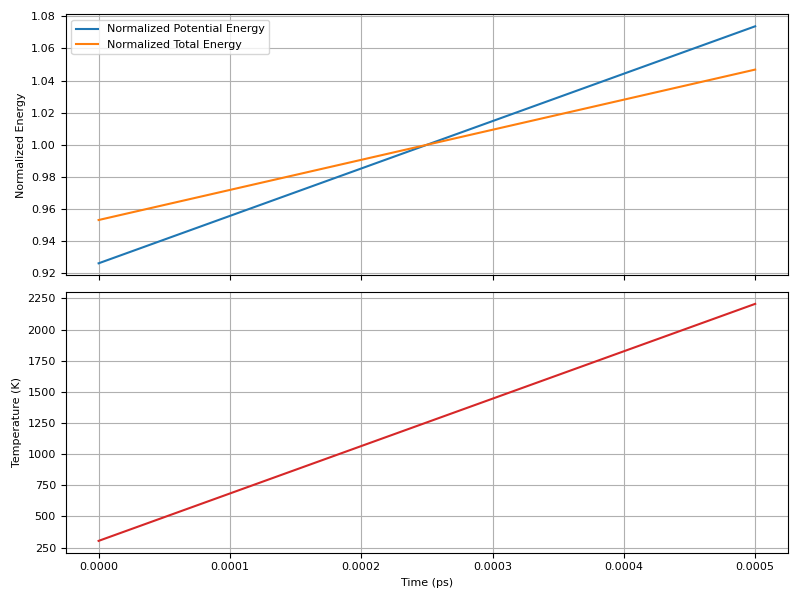

In [66]:
# ── T4 Step 3: Plot energies and temperature from the T3 NVT trajectory ──────
import time
TRAJ_FILE   = os.path.join(os.path.abspath("."), "nvt_nacl_water.traj")
OUTPUT_PNG  = os.path.join(os.path.abspath("."), "nvt_nacl_water_analysis.png")
TIMESTEP_FS = 0.5   # must match the timestep used in run_nvt_md

# Pre-flight: confirm tool is actually assigned before streaming
assert "plot_nvt_trajectory" in pool.list_registered_tools(), \
    "plot_nvt_trajectory not in registry — run the t4-register cell first!"
assert "plot_nvt_trajectory" in pool.list_agent_tools("mace_md_specialist"), \
    "plot_nvt_trajectory not assigned to mace_md_specialist — run t4-register first!"
assert os.path.exists(TRAJ_FILE), f"Trajectory not found: {TRAJ_FILE}"

query_T4_run = (
    f"Plot the NVT trajectory at {TRAJ_FILE}. "
    f"Use a timestep of {TIMESTEP_FS} fs. "
    f"Save the figure to {OUTPUT_PNG}."
)

# Fresh thread each run to avoid cached ‘already done’ history
config_T4_run = {"configurable": {"thread_id": f"t4-run-{int(time.time())}"}}

print("── [enhancer] " + "─" * 44)
enhanced_T4_run = enhancer.enhance(query_T4_run)
print(enhanced_T4_run)
print()

print("── [supervisor] " + "─" * 42)
for chunk in pool.supervisor.stream(
    {"messages": [{"role": "user", "content": enhanced_T4_run}]},
    config=config_T4_run,
    recursion_limit=25,
):
    pretty_print_messages(chunk, last_message=True)

assert os.path.exists(OUTPUT_PNG), f"Expected {OUTPUT_PNG} to exist after T4"
print(f"\n✓ {OUTPUT_PNG} created ({os.path.getsize(OUTPUT_PNG)} bytes)")

# Display inline
from IPython.display import display, Image as IPImage
display(IPImage(OUTPUT_PNG))


---
## 3.6 — Final Integration Test: Full MD Workflow from a Single Prompt

Demonstrates that all registered capabilities can be orchestrated end-to-end
from a single natural-language request. No tool or agent names are mentioned —
the PromptEnhancer and `mace_md_specialist` determine the full sequence autonomously.

| Step | Tool invoked |
|------|--------------|
| Download MACE-MP-0b3 | `download_mace_model` |
| SMILES → XYZ | `smiles_to_xyz` |
| Pack simulation box | `packmol_build_system` |
| Run NVT MD | `run_nvt_md` |
| Plot trajectory | `plot_nvt_trajectory` |

── [enhancer] ────────────────────────────────────────────
Convert the methanol SMILES (CO) to a 3D structure and save it to /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/methanol.xyz using mace_md_specialist with smiles_to_xyz. Then build a periodic cubic box of 15.0 Angstrom containing 50 methanol molecules and save it to /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/methanol_box.xyz using mace_md_specialist with packmol_build_system. Download the MACE-MP-0b3 force field model and save it to /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/models using mace_md_specialist with download_mace_model. Run a 100-step NVT simulation at 300 K with a 0.5 fs timestep using ASE and save the trajectory to /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/methanol_nvt.traj using mace_md_specialist with run_nvt_md. Finally, plot the energy and temperature evolution and save the figure to /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/me

/groups/ycolon/group-envs/agentic-tutorials/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = 

Only one head found in the model: default. Skipping selection.


/groups/ycolon/group-envs/agentic-tutorials/lib/python3.10/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


Running Packmol to build system in a 15 A box...

################################################################################

 PACKMOL - Packing optimization for the automated generation of
 starting configurations for molecular dynamics simulations.
 
                                                             Version 21.1.0 

################################################################################

  Packmol must be run with: packmol < inputfile.inp 

  Userguide at: http://m3g.iqm.unicamp.br/packmol 

  Reading input file... (Control-C aborts)
  Types of coordinate files specified: xyz
  Seed for random number generator:        12345
  Output file: /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/methanol_box.xyz
  Reading coordinate file: /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/methanol.xyz
  Number of independent structures:            1
  The structures are: 
  Structure            1 :SMILES: CO(           6  atoms)
  Maximum number o

Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.
Model 'MACE-MP-0b3' already exists at /scratch365/omendibl/Molec_Mindset/DynaMate2_prod/tutorials/models/mace-mp-0b3-medium.model. Skipping download.


Using head default out of ['default']
No dtype selected, switching to float64 to match model dtype.
Step:       0 | Pot. Energy:   -1419.8550 eV | Density: 0.7883 g/cm³
Step:      10 | Pot. Energy:   -1464.2470 eV | Density: 0.7883 g/cm³
Step:      20 | Pot. Energy:   -1471.6977 eV | Density: 0.7883 g/cm³
Step:      30 | Pot. Energy:   -1477.2321 eV | Density: 0.7883 g/cm³
Step:      40 | Pot. Energy:   -1475.8623 eV | Density: 0.7883 g/cm³
Step:      50 | Pot. Energy:   -1477.8921 eV | Density: 0.7883 g/cm³
Step:      60 | Pot. Energy:   -1479.2968 eV | Density: 0.7883 g/cm³
Step:      70 | Pot. Energy:   -1485.9989 eV | Density: 0.7883 g/cm³
Step:      80 | Pot. Energy:   -1484.5727 eV | Density: 0.7883 g/cm³
Step:      90 | Pot. Energy:   -1482.8187 eV | Density: 0.7883 g/cm³
Step:     100 | Pot. Energy:   -1483.6513 eV | Density: 0.7883 g/cm³
Update from node mace_md_specialist:

================================= Tool Message =================================
Name: transfer_back_to

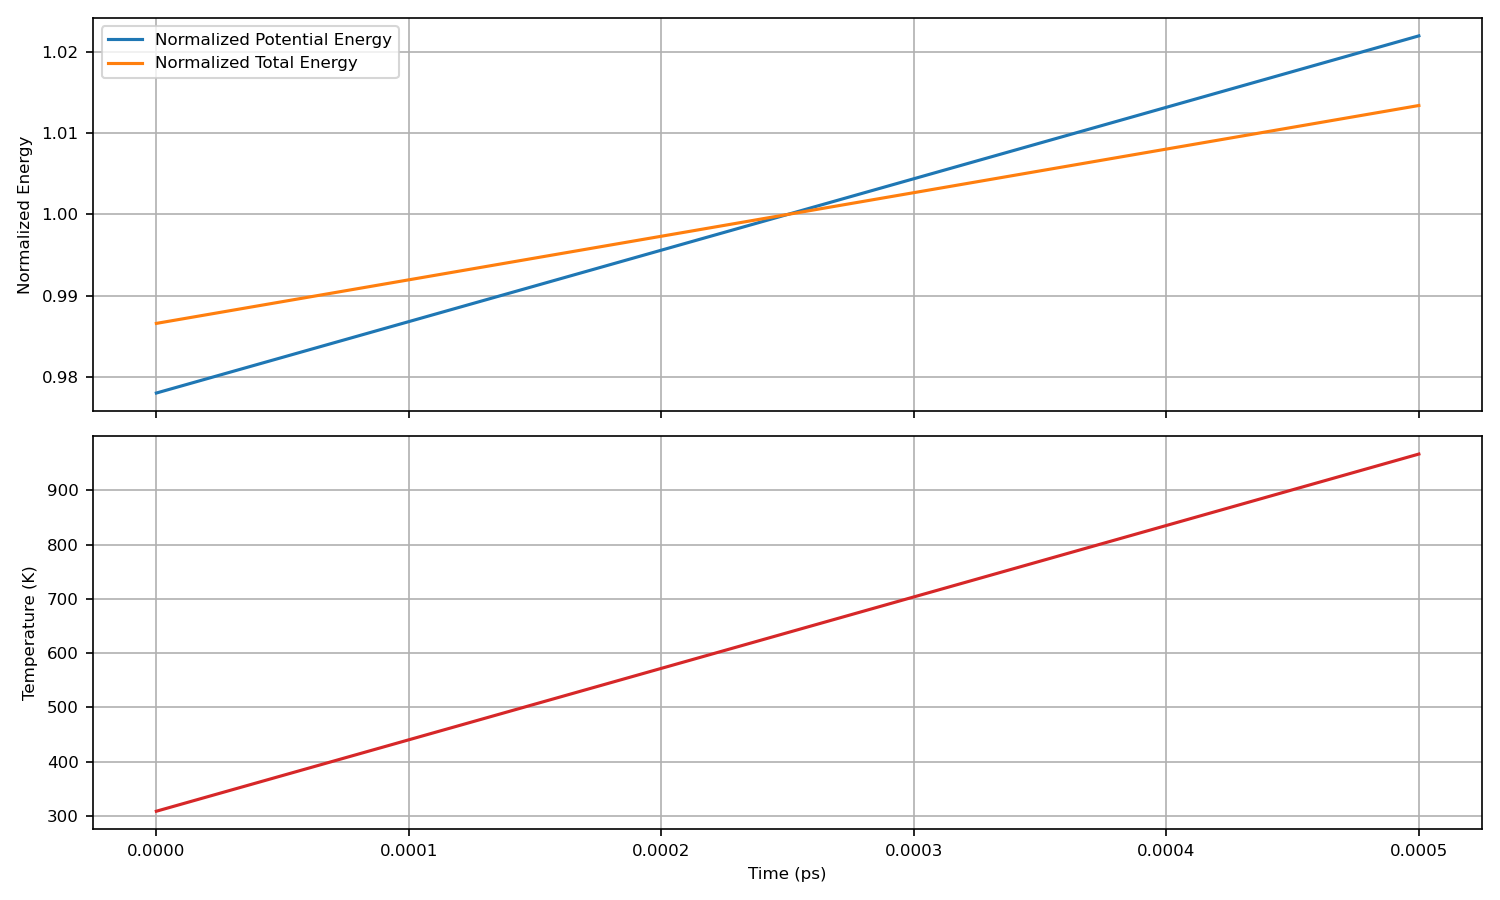

In [64]:
# ── Final Integration Test: full MD workflow from a single prompt ─────────────
# Uses methanol (SMILES: CO) — a fresh molecule not cached from T1–T4 —
# so all preparation steps are forced to run from scratch.
import time

# ── Output paths ──────────────────────────────────────────────────────────────
MODELS_DIR   = os.path.join(os.path.abspath('.'), 'models')
INT_MOL_XYZ  = os.path.join(os.path.abspath('.'), 'methanol.xyz')
INT_BOX_XYZ  = os.path.join(os.path.abspath('.'), 'methanol_box.xyz')
INT_TRAJ     = os.path.join(os.path.abspath('.'), 'methanol_nvt.traj')
INT_PNG      = os.path.join(os.path.abspath('.'), 'methanol_nvt_analysis.png')
INT_BOX_SIZE = 15.0   # Å — 50 MeOH molecules at ~0.791 g/cm³

query_final = (
    "I need a complete NVT molecular dynamics study of liquid methanol from scratch. "
    f"Use the MACE-MP-0b3 force field and save the model to {MODELS_DIR}. "
    f"Convert the methanol SMILES (CO) to a 3D structure and save it to {INT_MOL_XYZ}. "
    f"Build a periodic cubic box of {INT_BOX_SIZE} Angstrom containing 50 methanol "
    f"molecules and save it to {INT_BOX_XYZ}. "
    "Run a 100-step NVT simulation at 300 K with a 0.5 fs timestep using ASE "
    f"and save the trajectory to {INT_TRAJ}. "
    f"Finally, plot the energy and temperature evolution and save the figure to {INT_PNG}."
)

# Fresh thread — no history from T1–T4
config_final = {'configurable': {'thread_id': f'final-integration-{int(time.time())}'}}

print('── [enhancer] ' + '─' * 44)
enhanced_final = enhancer.enhance(query_final)
print(enhanced_final)
print()

print('── [supervisor] ' + '─' * 42)
for chunk in pool.supervisor.stream(
    {'messages': [{'role': 'user', 'content': enhanced_final}]},
    config=config_final,
    recursion_limit=30,
):
    pretty_print_messages(chunk, last_message=True)

# ── Assertions ────────────────────────────────────────────────────────────────
assert os.path.exists(INT_MOL_XYZ), f'Missing: {INT_MOL_XYZ}'
assert os.path.exists(INT_BOX_XYZ), f'Missing: {INT_BOX_XYZ}'
assert os.path.exists(INT_TRAJ),    f'Missing: {INT_TRAJ}'
assert os.path.exists(INT_PNG),     f'Missing: {INT_PNG}'
print(f'\n✓ methanol.xyz              ({os.path.getsize(INT_MOL_XYZ)} bytes)')
print(f'✓ methanol_box.xyz          ({os.path.getsize(INT_BOX_XYZ)} bytes)')
print(f'✓ methanol_nvt.traj         ({os.path.getsize(INT_TRAJ)} bytes)')
print(f'✓ methanol_nvt_analysis.png ({os.path.getsize(INT_PNG)} bytes)')

from IPython.display import display, Image as IPImage
display(IPImage(INT_PNG))